In [19]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip, sigma_clipped_stats
from astropy.time import Time, TimeDelta
from tqdm import tqdm as tqdm
import galsim
import pandas as pd
from matplotlib.dates import DateFormatter
from functools import partial
from numpy.polynomial.polynomial import polyval, polyval2d
from lsst_efd_client import EfdClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib.colors import Normalize
import matplotlib.cm as cm  # For colormap
from lsst.summit.utils import (
    ConsDbClient, 
    getBandpassSeeingCorrection, 
    getAirmassSeeingCorrection,
    makeDefaultButler
)
import yaml
from lsst.obs.lsst import LsstCam
from lsst.sitcom.vandv.lasertracker import utils
from numpy.polynomial import Polynomial
%matplotlib inline
%load_ext autoreload
%autoreload 2

all_labels = ['M2 dz', 'M2 dx', 'M2 dy', 'M2 rx', 'M2 ry',
     'cam dz', 'cam dx', 'cam dy', 'cam rx', 'cam ry',
     '$B_{{1,1}}$', '$B_{{1,2}}$', '$B_{{1,3}}$', '$B_{{1,4}}$', '$B_{{1,5}}$',
     '$B_{{1,6}}$', '$B_{{1,7}}$', '$B_{{1,8}}$', '$B_{{1,9}}$', '$B_{{1,10}}$',
     '$B_{{1,11}}$', '$B_{{1,12}}$', '$B_{{1,13}}$', '$B_{{1,14}}$', '$B_{{1,15}}$',
     '$B_{{1,16}}$', '$B_{{1,17}}$', '$B_{{1,18}}$', '$B_{{1,19}}$', '$B_{{1,20}}$',
     '$B_{{2,1}}$', '$B_{{2,2}}$', '$B_{{2,3}}$', '$B_{{2,4}}$', '$B_{{2,5}}$',
     '$B_{{2,6}}$', '$B_{{2,7}}$', '$B_{{2,8}}$', '$B_{{2,9}}$', '$B_{{2,10}}$',
     '$B_{{2,11}}$', '$B_{{2,12}}$', '$B_{{2,13}}$', '$B_{{2,14}}$', '$B_{{2,15}}$',
     '$B_{{2,16}}$', '$B_{{2,17}}$', '$B_{{2,18}}$', '$B_{{2,19}}$', '$B_{{2,20}}$'
     ]

home_path = os.getenv("HOME")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
client = EfdClient('summit_efd')
fields = ['dX', 'dY', 'dZ', 'dRX', 'dRY', 'dRZ','target']

start = Time("2025-09-04 21:40:00Z", scale='utc')
end = Time("2025-09-04 23:15:00Z", scale='utc')

no_open_loop = await client.select_time_series(
    'lsst.sal.LaserTracker.logevent_offsetsPublish',
    fields,  
    start, 
    end,
)
laser_cam = utils.extract_component_data(no_open_loop, 'Camera')
laser_m2 = utils.extract_component_data(no_open_loop, 'M2')

In [24]:
lut_path_update = os.path.join(
    home_path,
    "notebooks/lsst-ts/ts_config_mttcs/MTHexapod/v3/_init.yaml",
)

with open(lut_path_update, "r") as yaml_file:
    fea_lut_data = yaml.safe_load(yaml_file)

lut_path_update = os.path.join(
    home_path,
    "notebooks/lsst-ts/ts_config_mttcs/MTHexapod/v6/laser_rotation_elevation_v5.yaml",
)

with open(lut_path_update, "r") as yaml_file:
    lut_data = yaml.safe_load(yaml_file)

m2_coeffs = lut_data["m2_config"]["elevation_rotation_coeffs"]
camera_coeffs = lut_data["camera_config"]["elevation_rotation_coeffs"]

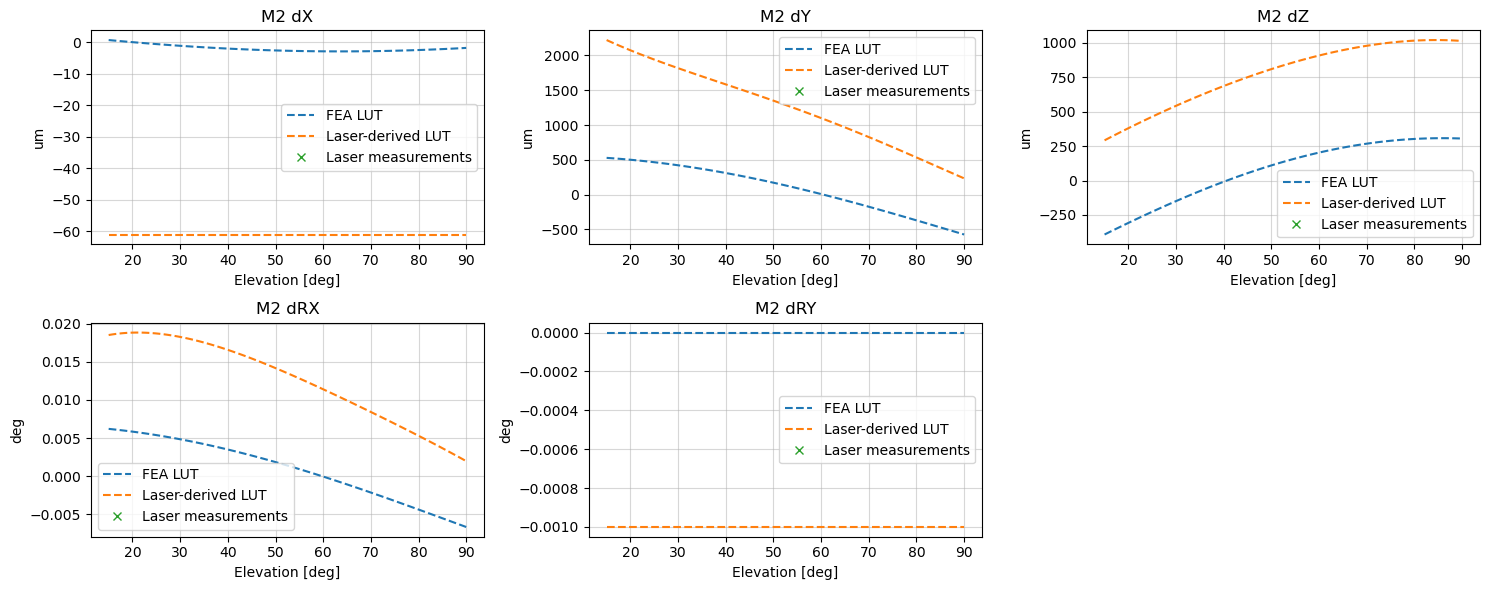

In [41]:
# --- M2 config (1D polys in elevation only) ---
m2_polys = [partial(polyval, c=np.array(coeff)) for coeff in m2_coeffs if isinstance(coeff, list)]

lut_data_mapping = {
    0: 2,
    1: 0,
    2: 1,
    3: 3,
    4: 4,
}

el = np.linspace(15, 90, 100)  # elevation in degrees
plt.figure(figsize=(15, 6))
for idx, poly in enumerate(m2_polys[:-1]):
    x_fit = el
    Z = poly(x_fit)  # only elevation

    coefs_fea_lut = fea_lut_data["m2_config"]["elevation_coeffs"][idx]
    coefs_fea_lut = np.array(coefs_fea_lut)
    poly_fea_lut = np.poly1d(coefs_fea_lut[::-1])
    y_fea_lut = poly_fea_lut(x_fit)

    ax = plt.subplot(2, 3, idx + 1)
    ax.plot(x_fit, y_fea_lut, '--', label=f"FEA LUT")
    ax.plot(x_fit, Z.squeeze(), '--', label=f"Laser-derived LUT")
    ax.plot(laser_m2['target_elevation'], laser_m2[fields[idx]], 'x', label='Laser measurements')
    ax.set_xlabel("Elevation [deg]")

    if idx < 3:
        ax.set_ylabel("um")
    else:
        ax.set_ylabel("deg")
    ax.set_title(f"M2 {fields[idx]}")
    ax.grid(True, alpha = 0.5)
    ax.legend()

plt.tight_layout()
plt.show()

dX coeff shape: (3, 6)
dY coeff shape: (3, 6)
dZ coeff shape: (3, 4)
dRX coeff shape: (3, 4)
dRY coeff shape: (3, 4)


/scratch/gmegias/tmp/ipykernel_56481/4134010150.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Z = polyval2d(np.full_like(x_fit, laser_cam['target_elevation'][0]), x_fit, coeffs)


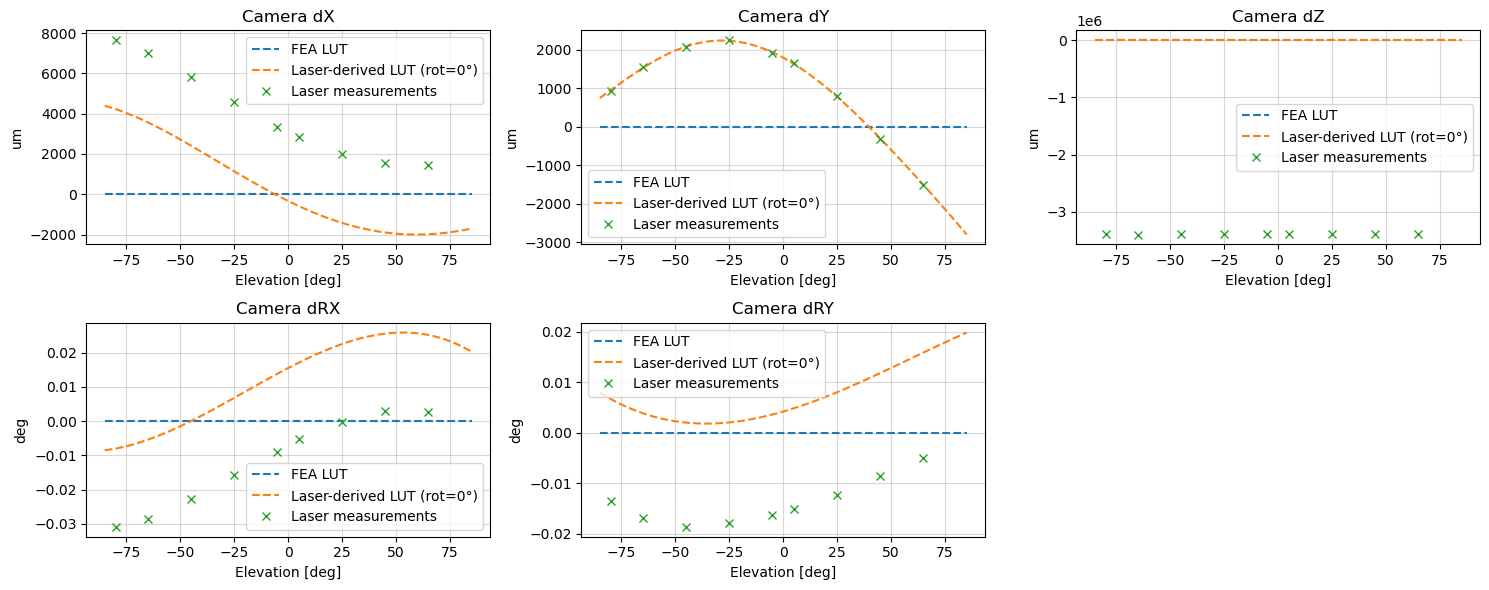

In [42]:
rot = np.linspace(-85, 85, 100)  # elevation in degrees
plt.figure(figsize=(15, 6))
for idx, poly in enumerate(range(5)):
    coeffs = np.array(camera_coeffs[idx])
    x_fit = rot
    print(f"{fields[idx]} coeff shape:", coeffs.shape)

    Z = polyval2d(np.full_like(x_fit, laser_cam['target_elevation'][0]), x_fit, coeffs)
    
    coefs_fea_lut = fea_lut_data["camera_config"]["rotation_coeffs"][idx]
    coefs_fea_lut = np.array(coefs_fea_lut)
    poly_fea_lut = np.poly1d(coefs_fea_lut[::-1])
    y_fea_lut = poly_fea_lut(x_fit)

    ax = plt.subplot(2, 3, idx + 1)
    ax.plot(x_fit, y_fea_lut, '--', label=f"FEA LUT")
    ax.plot(x_fit, Z, '--', label="Laser-derived LUT (rot=0°)", linewidth=1.5)
    ax.plot(laser_cam['target_rotation'], -laser_cam[fields[idx]], 'x', label='Laser measurements')
    ax.set_xlabel("Elevation [deg]")
    

    if idx < 3:
        ax.set_ylabel("um")
    else:
        ax.set_ylabel("deg")
    ax.set_title(f"Camera {fields[idx]}")
    ax.grid(True, alpha = 0.5)
    ax.legend()

plt.tight_layout()
plt.show()

dX coeff shape: (3, 6)
dY coeff shape: (3, 6)
dZ coeff shape: (3, 4)
dRX coeff shape: (3, 4)
dRY coeff shape: (3, 4)


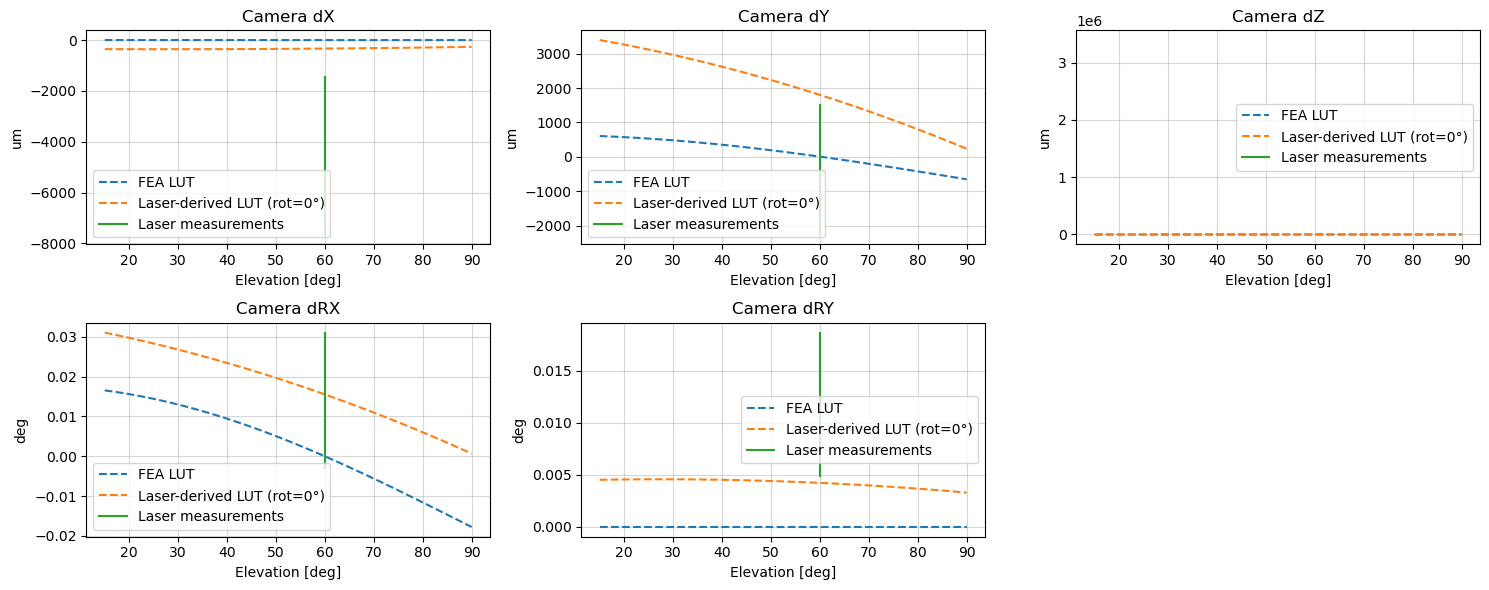

In [43]:
el = np.linspace(15, 90, 100)  # elevation in degrees
plt.figure(figsize=(15, 6))
for idx, poly in enumerate(range(5)):
    coeffs = np.array(camera_coeffs[idx])
    x_fit = el
    print(f"{fields[idx]} coeff shape:", coeffs.shape)

    Z = polyval2d(x_fit, np.full_like(x_fit, 0.0), coeffs)
    
    coefs_fea_lut = fea_lut_data["camera_config"]["elevation_coeffs"][idx]
    coefs_fea_lut = np.array(coefs_fea_lut)
    poly_fea_lut = np.poly1d(coefs_fea_lut[::-1])
    y_fea_lut = poly_fea_lut(x_fit)

    ax = plt.subplot(2, 3, idx + 1)
    ax.plot(x_fit, y_fea_lut, '--', label=f"FEA LUT")
    ax.plot(x_fit, Z, '--', label="Laser-derived LUT (rot=0°)", linewidth=1.5)
    ax.plot(laser_cam['target_elevation'], laser_cam[fields[idx]], label='Laser measurements')
    ax.set_xlabel("Elevation [deg]")
    

    if idx < 3:
        ax.set_ylabel("um")
    else:
        ax.set_ylabel("deg")
    ax.set_title(f"Camera {fields[idx]}")
    ax.grid(True, alpha = 0.5)
    ax.legend()

plt.tight_layout()
plt.show()